In [17]:
from amuse.io import write_set_to_file
from amuse.units import units
from amuse.lab import Particles

from make_system import SystemMaker

import numpy as np
import matplotlib.pyplot as plt

In [22]:
np.sqrt(1.6e-6 * 1.396e-4)

1.4945233353815524e-05

In [ ]:
maker = SystemMaker(
    smbh_mass=4.279e6 | units.MSun,
    orbiter_mass=[2.8, 0.73] | units.MSun,
    outer_semimajor_axis=44e-3 | units.pc,
    outer_eccentricity=0.32,
    inner_semimajor_axis=1.59 | units.AU,
    inner_eccentricity=0.45,
    mutual_inclination=102.55 | units.deg,
    inner_arg_of_periapse=311.75 | units.deg,
    disk_inner_radius=8.32 | units.AU,
    disk_outer_radius=11.35 | units.AU,
    # disk_mass=1.6e-6 | units.Msun,
    # disk_mass=1.396e-4 | units.MSun,
    disk_mass=1.49e-5 | units.Msun,
    n_disk=int(1e5)
)

Initializing a binary around a black hole.


In [19]:
smbh_and_binary, disk, converter = maker.make_system()

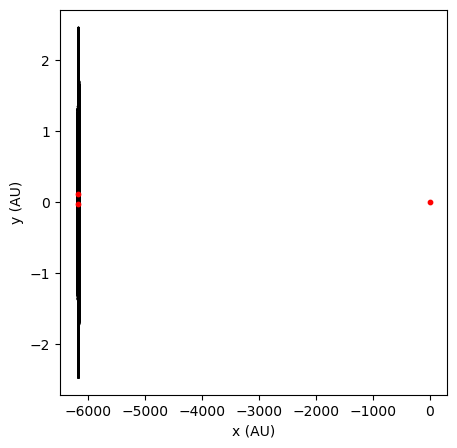

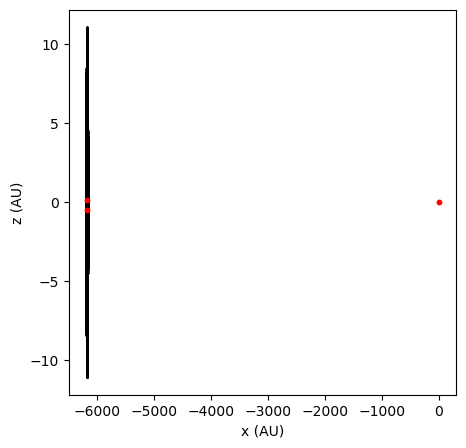

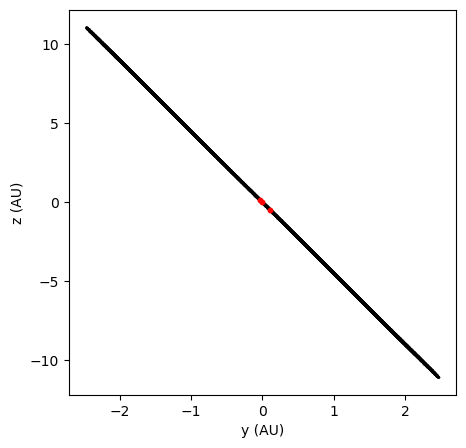

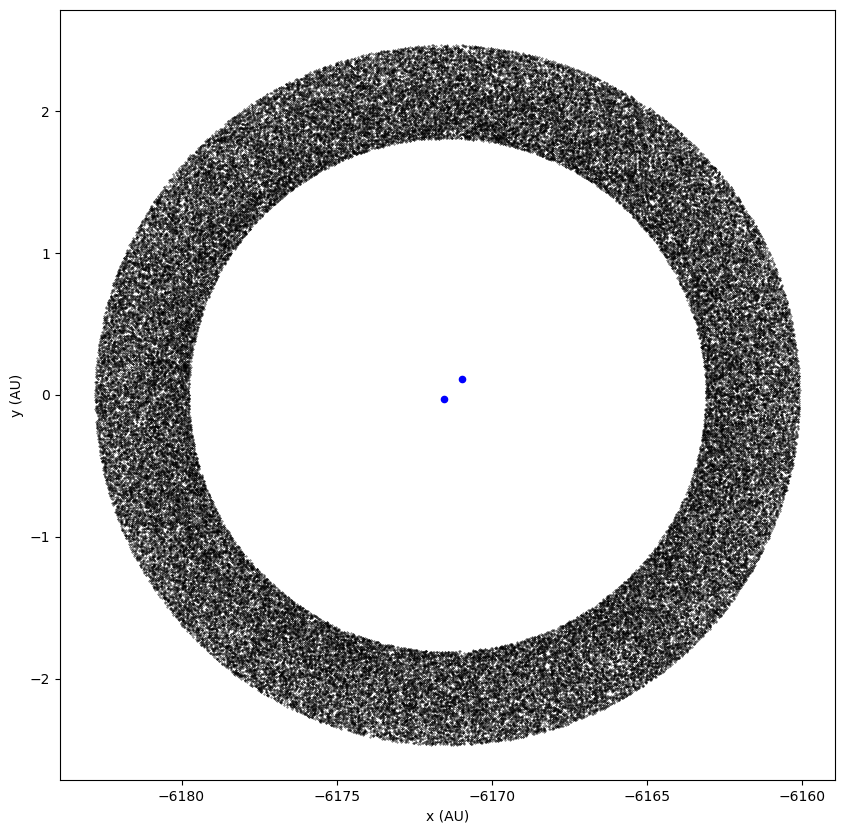

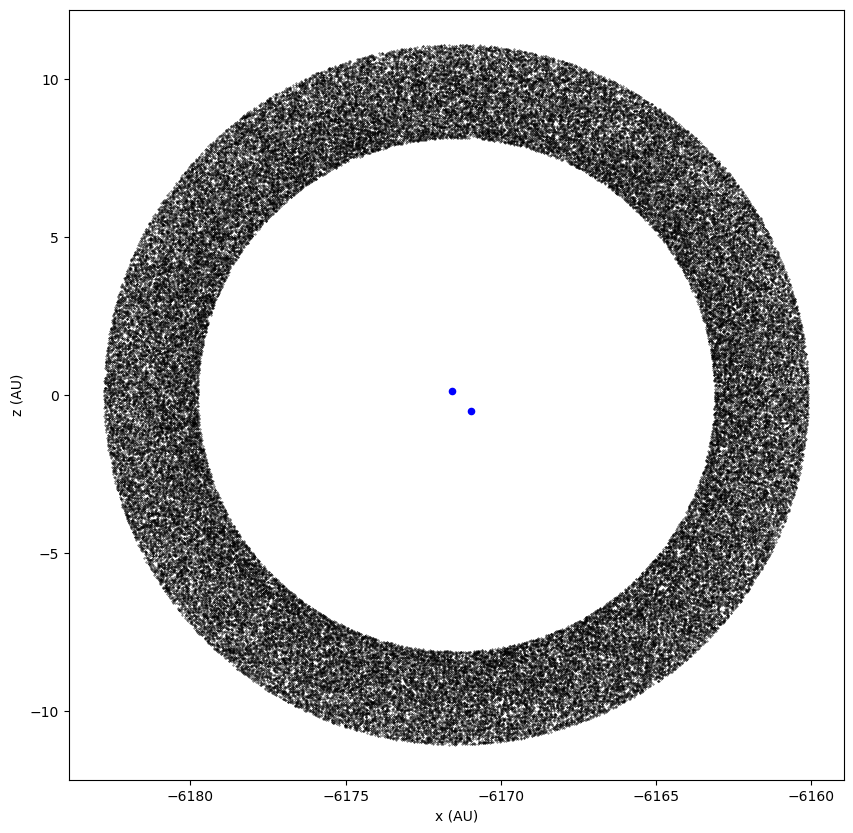

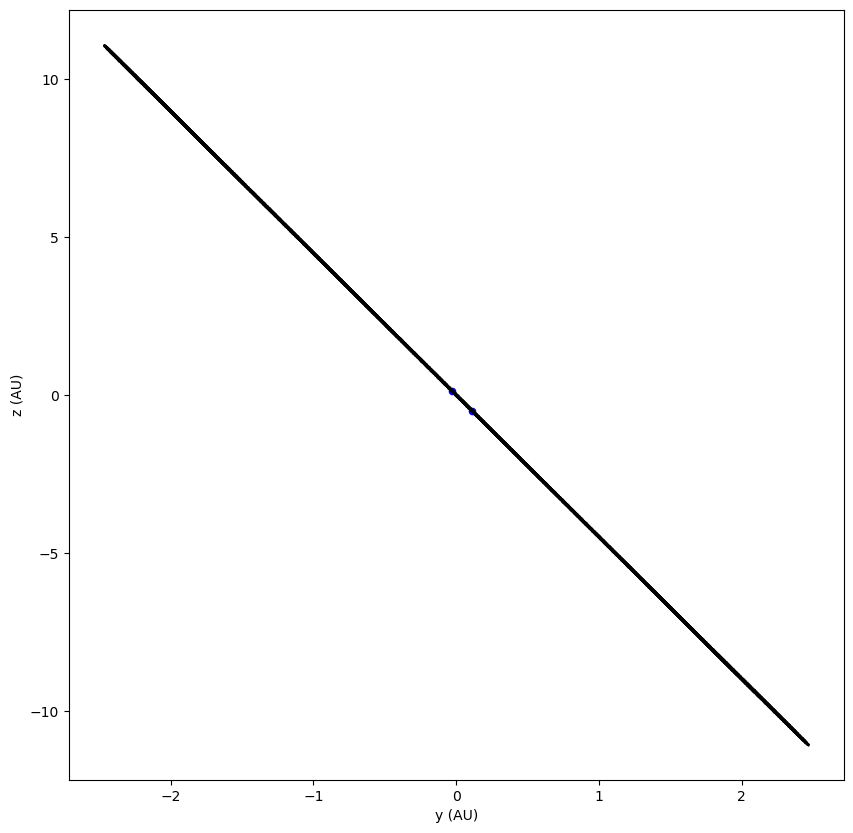

In [20]:
plt.figure(figsize=(5, 5))
plt.scatter(disk.x.value_in(units.AU), disk.y.value_in(units.AU), s=0.1, color='k')
plt.scatter(smbh_and_binary.x.value_in(units.AU), smbh_and_binary.y.value_in(units.AU), s=10, color='r')
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(disk.x.value_in(units.AU), disk.z.value_in(units.AU), s=0.1, color='k')
plt.scatter(smbh_and_binary.x.value_in(units.AU), smbh_and_binary.z.value_in(units.AU), s=10, color='r')
plt.xlabel("x (AU)")
plt.ylabel("z (AU)")
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(disk.y.value_in(units.AU), disk.z.value_in(units.AU), s=0.1, color='k')
plt.scatter(smbh_and_binary.y.value_in(units.AU), smbh_and_binary.z.value_in(units.AU), s=10, color='r')
plt.xlabel("y (AU)")
plt.ylabel("z (AU)")
plt.show()

stars = smbh_and_binary[smbh_and_binary.mass < 10 | units.MSun]

plt.figure(figsize=(10, 10))
plt.scatter(stars.x.value_in(units.AU), stars.y.value_in(units.AU), s=20, color='b')
# plt.scatter(smbh_and_binary.x.value_in(units.AU), smbh_and_binary.y.value_in(units.AU), s=10, color='r')
plt.scatter(disk.x.value_in(units.AU), disk.y.value_in(units.AU), s=0.1, color='k')
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.show()

plt.figure(figsize=(10, 10))
plt.scatter(stars.x.value_in(units.AU), stars.z.value_in(units.AU), s=20, color='b')
plt.scatter(disk.x.value_in(units.AU), disk.z.value_in(units.AU), s=0.1, color='k')
plt.xlabel("x (AU)")
plt.ylabel("z (AU)")
plt.show()

plt.figure(figsize=(10, 10))
plt.scatter(stars.y.value_in(units.AU), stars.z.value_in(units.AU), s=20, color='b')
plt.scatter(disk.y.value_in(units.AU), disk.z.value_in(units.AU), s=0.1, color='k')
plt.xlabel("y (AU)")
plt.ylabel("z (AU)")
plt.show()

In [ ]:
bodies = Particles()
bodies.add_particles(smbh_and_binary)
bodies.add_particles(disk)

# write_set_to_file(bodies, "initial_conditions_1_obs_mass.hdf5", "hdf5")
# write_set_to_file(bodies, "initial_conditions_2_orig_mass.hdf5", "hdf5")
write_set_to_file(bodies, "initial_conditions_3_between_mass.hdf5", "hdf5")